In [1]:
import networkx as nx

G = nx.Graph()

# Add pins
pins = ["pin1", "pin2", "pin3", "pin4", "pin5"]
G.add_nodes_from(pins, type="pin")

# Add boards
boards = ["boardA", "boardB", "boardC"]
G.add_nodes_from(boards, type="board")

# Add edges (pin saved to board)
edges = [
    ("pin1", "boardA"),
    ("pin2", "boardA"),
    ("pin3", "boardA"),
    ("pin2", "boardB"),
    ("pin4", "boardB"),
    ("pin5", "boardC"),
    ("pin3", "boardC"),
]

G.add_edges_from(edges)

In [2]:
import random

def random_walk(G, start_node, walk_length=6):
    node = start_node
    walk = [node]

    for _ in range(walk_length):
        neighbors = list(G.neighbors(node))
        if not neighbors:
            break

        node = random.choice(neighbors)
        walk.append(node)

    return walk

In [3]:
from collections import defaultdict

def pixie_recommend(G, query_pins, num_walks=1000, walk_length=6, top_k=5):
    
    visit_counts = defaultdict(int)

    for pin in query_pins:

        for _ in range(num_walks):

            walk = random_walk(G, pin, walk_length)

            for node in walk:
                if G.nodes[node]["type"] == "pin" and node not in query_pins:
                    visit_counts[node] += 1

    ranked = sorted(visit_counts.items(), key=lambda x: x[1], reverse=True)

    return ranked[:top_k]

In [4]:
query = ["pin1"]

recommendations = pixie_recommend(G, query)

print("Recommendations:")
for pin, score in recommendations:
    print(pin, score)

Recommendations:
pin3 964
pin2 945
pin4 213
pin5 185


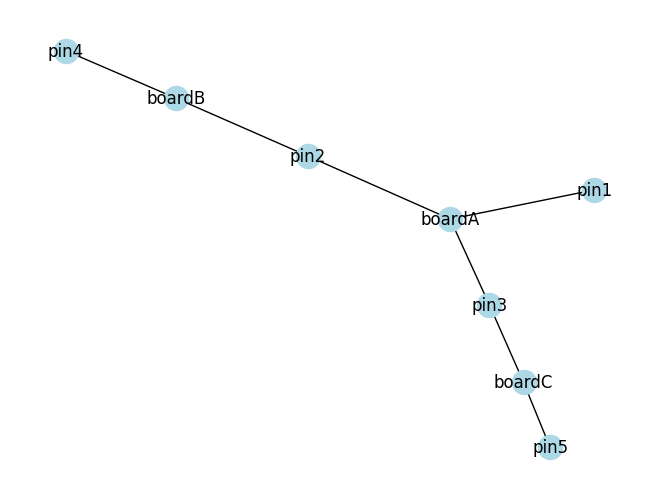

In [5]:
import matplotlib.pyplot as plt

nx.draw(G, with_labels=True, node_color="lightblue")
plt.show()